In [5]:
import sys
import os
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))

from utilities.log_processor import LogProcessor

In [6]:
processor = LogProcessor('../../logs/nothing_bot@07_04_2025_1300.log')
processor.read_log()

In [7]:
import pandas as pd

price_data = pd.concat([pd.read_csv('../../round_data/prices_round_1_day_-2.csv',delimiter=';'), pd.read_csv('../../round_data/prices_round_1_day_-1.csv',delimiter=';'), pd.read_csv('../../round_data/prices_round_1_day_0.csv',delimiter=';'), processor.activities_log],axis=0)
price_data = price_data.reset_index(drop=True)

day_2 = pd.read_csv("../../round_data/trades_round_1_day_-2.csv",delimiter=';')
day_1 = pd.read_csv("../../round_data/trades_round_1_day_-1.csv",delimiter=';')
day_1['timestamp'] = day_1['timestamp'] + 1e6
day_0 = pd.read_csv("../../round_data/trades_round_1_day_0.csv",delimiter=';')
day_0['timestamp'] = day_0['timestamp'] + 1e6*2
processor.trade_history['timestamp'] = processor.trade_history['timestamp'] + 1e6*3
trade_history_data = pd.concat([day_2,day_1,day_0,processor.trade_history], axis=0)
trade_history_data = trade_history_data.reset_index(drop=True)

In [8]:
price_data['timestamp'] = price_data['timestamp'] + (price_data['day']+2)*1e6

In [358]:
kelp_data = price_data[price_data['product'] == "KELP"].copy()
resin_data = price_data[price_data['product'] == "RAINFOREST_RESIN"].copy()
squid_data = price_data[price_data['product'] == "SQUID_INK"].copy()

kelp_trades = trade_history_data[trade_history_data['symbol'] == "KELP"].copy()
resin_trades = trade_history_data[trade_history_data['symbol'] == "RAINFOREST_RESIN"].copy()
squid_trades = trade_history_data[trade_history_data['symbol'] == "SQUID_INK"].copy()

# Regression

In [359]:
squid_data["highest_vol_bid_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"bid_volume_{i}"] for i in range(1,4)]),axis=1)
squid_data["highest_vol_bid"] = squid_data.apply(lambda row : row[f"bid_price_{row['highest_vol_bid_idx']}"],axis=1)

squid_data["highest_vol_ask_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"ask_volume_{i}"] for i in range(1,4)]),axis=1)
squid_data["highest_vol_ask"] = squid_data.apply(lambda row : row[f"ask_price_{row['highest_vol_ask_idx']}"],axis=1)

squid_data['adjusted_mid'] = (squid_data['highest_vol_ask']+squid_data['highest_vol_bid'])/2

In [360]:
squid_data['adjusted_mid_change'] = squid_data['adjusted_mid'].pct_change()

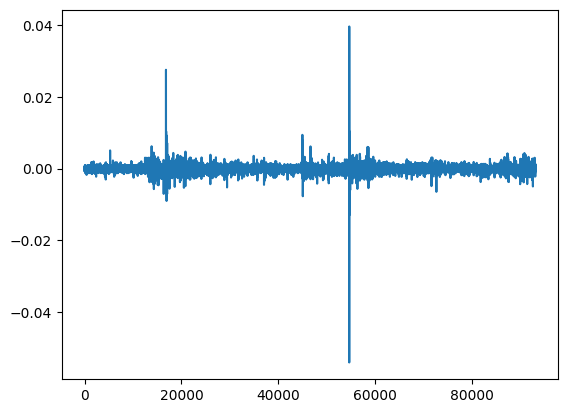

In [361]:
plt.plot(squid_data['adjusted_mid'].pct_change())

0.001182054165445773

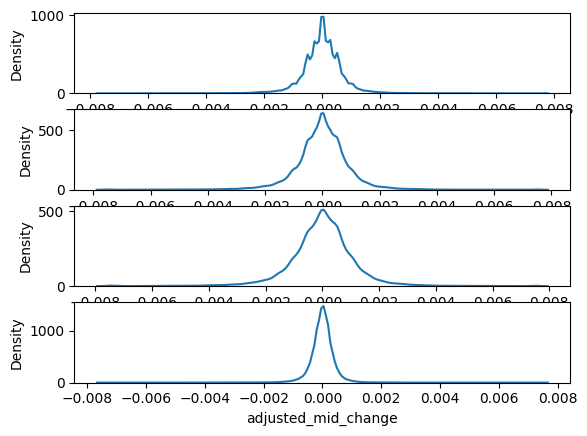

In [362]:
fig,ax = plt.subplots(nrows=4)
sns.kdeplot(np.clip(squid_data['adjusted_mid_change'],-0.0075,0.0075),ax=ax[0])
sns.kdeplot(np.clip(squid_data['adjusted_mid'].pct_change(2),-0.0075,0.0075),ax=ax[1])
sns.kdeplot(np.clip(squid_data['adjusted_mid'].pct_change(3),-0.0075,0.0075),ax=ax[2])
sns.kdeplot(np.clip(squid_data['adjusted_mid_change'].rolling(3).mean(),-0.0075,0.0075),ax=ax[3])
np.std(np.clip(squid_data['adjusted_mid'].pct_change(3),-0.0075,0.0075))

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

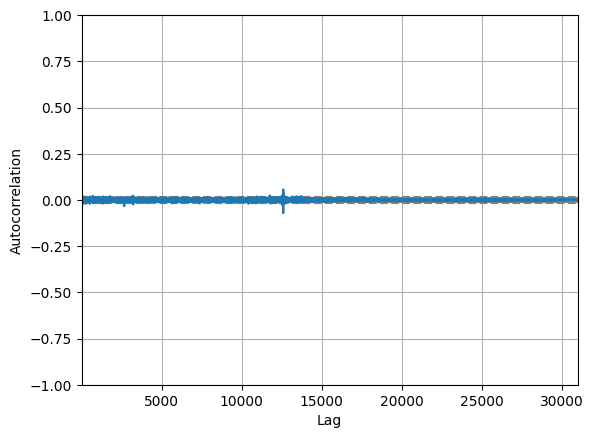

In [363]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(squid_data['adjusted_mid_change'].dropna())

In [364]:
ave_mag = abs(squid_data['adjusted_mid_change']).mean()
print("Average magnitude of change: ", abs(squid_data['adjusted_mid_change']).mean())

Average magnitude of change:  0.0004743671654549984


[-0.11088975]
MSE loss:  0.03379933499771636
MSE loss ave magnitude ratio:  71.25142180803572
[-3.03147727e-06 -1.10901626e-01]
MSE loss:  0.03383692647497183
MSE loss ave magnitude ratio:  71.33066733764444


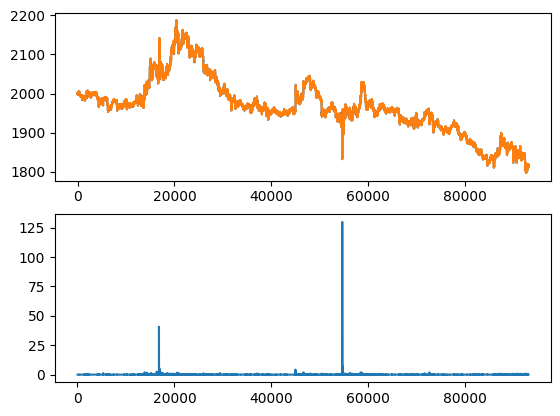

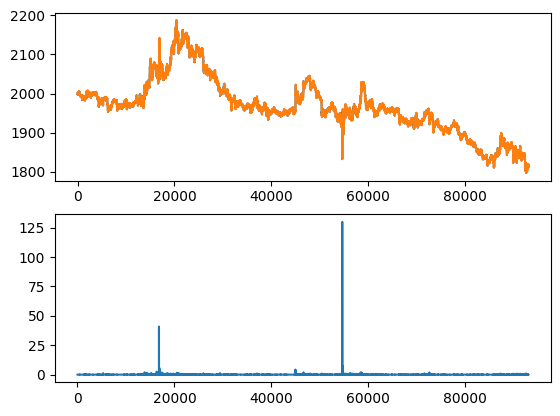

In [365]:
"""
Using last returns to predict future returns
"""
import statsmodels.api as sm
df = pd.concat([squid_data['adjusted_mid_change'].shift(1),squid_data['adjusted_mid_change']],axis=1)
df = df.dropna()

model = sm.OLS(df.iloc[:,1].values, df.iloc[:,0].values)
results = model.fit()
print(results.params)
coeff = results.params[0]
predicted = squid_data['adjusted_mid']*(1+squid_data['adjusted_mid_change'].shift(1)*coeff )
fig,ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(predicted)

ax[1].plot((predicted-squid_data['adjusted_mid'])**2)
MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
print("MSE loss: ", MSE_loss)
print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)

model = sm.OLS(df.iloc[:,1].values, sm.add_constant(df.iloc[:,0].values))
results = model.fit()
print(results.params)

intercept = results.params[0]
coeff = results.params[1]
predicted = squid_data['adjusted_mid']*(1+squid_data['adjusted_mid_change'].shift(1)*coeff + intercept)
fig,ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(predicted)

ax[1].plot((predicted-squid_data['adjusted_mid'])**2)
MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
print("MSE loss: ", MSE_loss)
print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)

[-0.04831253]
MSE loss:  0.0064157128287072795
MSE loss ave magnitude ratio:  13.524782691385322
[-3.34092444e-06 -4.83329617e-02]
MSE loss:  0.0064618561313132886
MSE loss ave magnitude ratio:  13.622056082054657


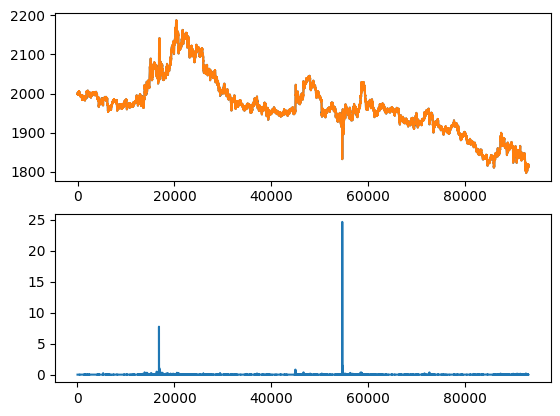

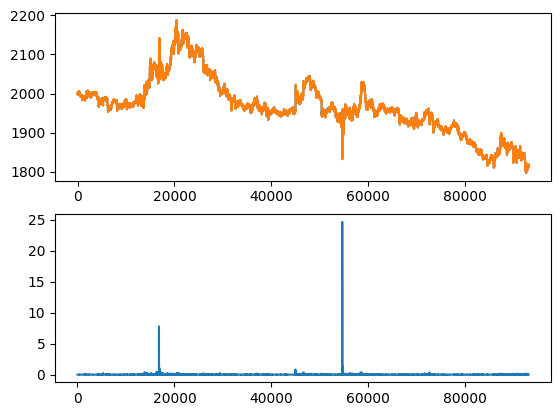

In [366]:
"""
Using last returns to predict future returns, with data clipped
"""
import statsmodels.api as sm
df = pd.concat([squid_data['adjusted_mid_change'].shift(1),squid_data['adjusted_mid_change']],axis=1)
df = df.dropna()
df = df.clip(-0.0075,0.0075)

model = sm.OLS(df.iloc[:,1].values, df.iloc[:,0].values)
results = model.fit()
print(results.params)
coeff = results.params[0]
predicted = squid_data['adjusted_mid']*(1+squid_data['adjusted_mid_change'].shift(1)*coeff )
fig,ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(predicted)

ax[1].plot((predicted-squid_data['adjusted_mid'])**2)
MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
print("MSE loss: ", MSE_loss)
print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)

model = sm.OLS(df.iloc[:,1].values, sm.add_constant(df.iloc[:,0].values))
results = model.fit()
print(results.params)

intercept = results.params[0]
coeff = results.params[1]
predicted = squid_data['adjusted_mid']*(1+squid_data['adjusted_mid_change'].shift(1)*coeff + intercept)
fig,ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(predicted)

ax[1].plot((predicted-squid_data['adjusted_mid'])**2)
MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
print("MSE loss: ", MSE_loss)
print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)

[-0.03792289]
MSE loss:  0.0006431409393039033
MSE loss ave magnitude ratio:  1.3557872174542736


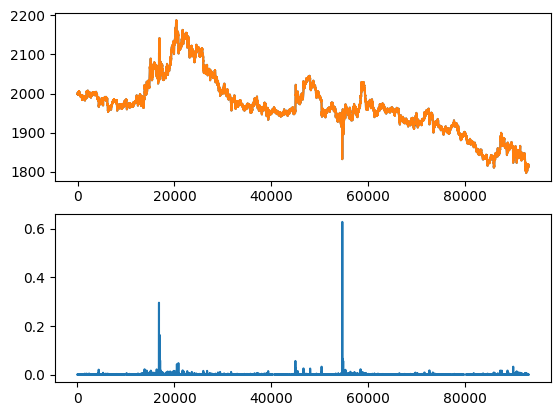

In [367]:
"""
Using rolling mean returns
"""
import statsmodels.api as sm
df = pd.concat([squid_data['adjusted_mid_change'].rolling(5).mean().shift(1),squid_data['adjusted_mid_change']],axis=1)
df = df.dropna()
df = df.clip(-0.0075,0.0075)

model = sm.OLS(df.iloc[:,1].values,df.iloc[:,0].values)
results = model.fit()
print(results.params)
# model = sm.OLS(sm.add_constant(df.iloc[:,0].values), df.iloc[:,1].values)
# results = model.fit()
# print(results.params)

coeff = results.params[0]
predicted = squid_data['adjusted_mid']*(1+squid_data['adjusted_mid_change'].rolling(5).mean().shift(1)*coeff)
fig,ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(predicted)

ax[1].plot((predicted-squid_data['adjusted_mid'])**2)
MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
print("MSE loss: ", MSE_loss)
print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)


Minimum loss: 6.539204746546342e-09 
MSE loss ave magnitude ratio:  1.3785112509366321e-05 
Rolling Window Size:  26 
Coeff:  0.00012092354333361616


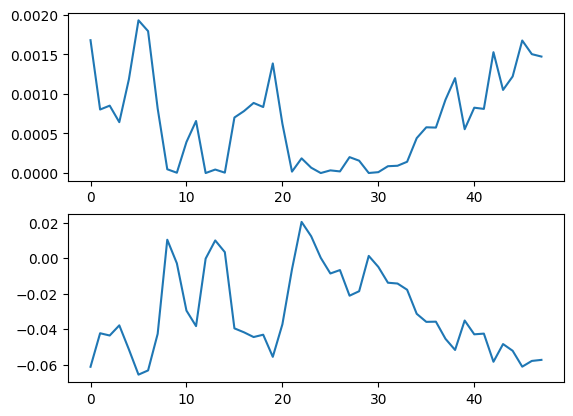

In [368]:
"""
Param search for rolling window:
"""

import statsmodels.api as sm
fig,ax = plt.subplots(nrows=2)
MSE_losses = []
coeffs = []
for n in range(2,50):
    df = pd.concat([squid_data['adjusted_mid_change'].rolling(n).mean().shift(1),squid_data['adjusted_mid_change']],axis=1)
    df = df.dropna()
    df = df.clip(-0.0075,0.0075)

    model = sm.OLS(df.iloc[:,1].values,df.iloc[:,0].values)
    results = model.fit()
    # print(results.params)
    # model = sm.OLS(sm.add_constant(df.iloc[:,0].values), df.iloc[:,1].values)
    # results = model.fit()
    # print(results.params)

    coeff = results.params[0]
    predicted = squid_data['adjusted_mid']*(1+squid_data['adjusted_mid_change'].rolling(5).mean().shift(1)*coeff)
    MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
    # print("rolling window: ", n)
    # print("MSE loss: ", MSE_loss)
    MSE_losses.append(MSE_loss)
    coeffs.append(coeff)
    # print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)
ax[0].plot(MSE_losses)
ax[1].plot(coeffs)
print("\nMinimum loss:", min(MSE_losses), "\nMSE loss ave magnitude ratio: ", min(MSE_losses)/ave_mag, "\nRolling Window Size: ", 2+np.argmin(MSE_losses), "\nCoeff: ", coeffs[np.argmin(MSE_losses)])


[0.01639976]
MSE loss:  0.00012027571768721805
MSE loss ave magnitude ratio:  0.253549837438376


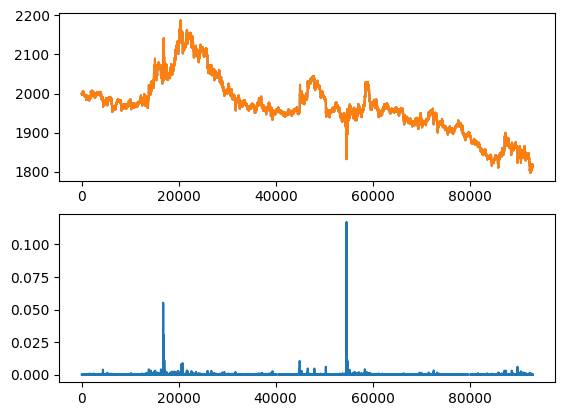

In [369]:
"""
Using rolling median returns
"""
import statsmodels.api as sm
df = pd.concat([squid_data['adjusted_mid_change'].rolling(5).mean().shift(5),squid_data['adjusted_mid_change']],axis=1)
df = df.dropna()
df = df.clip(-0.0075,0.0075)

model = sm.OLS(df.iloc[:,1].values,df.iloc[:,0].values)
results = model.fit()
print(results.params)
# model = sm.OLS(sm.add_constant(df.iloc[:,0].values), df.iloc[:,1].values)
# results = model.fit()
# print(results.params)

coeff = results.params[0]
predicted = squid_data['adjusted_mid']*(1+squid_data['adjusted_mid_change'].rolling(5).mean().shift(1)*coeff)
fig,ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(predicted)

ax[1].plot((predicted-squid_data['adjusted_mid'])**2)
MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
print("MSE loss: ", MSE_loss)
print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)


Minimum loss: 1.9578186889467107e-06 
MSE loss ave magnitude ratio:  0.00412722218467383 
Rolling Window Size:  29 
Coeff:  -0.002092351437167385


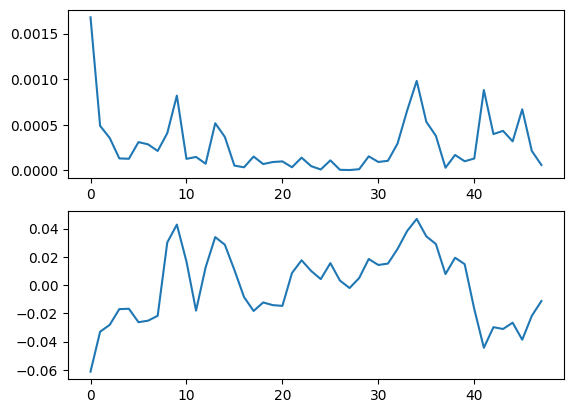

In [370]:
"""
Param search for rolling window:
"""

import statsmodels.api as sm
fig,ax = plt.subplots(nrows=2)
MSE_losses = []
coeffs = []
for n in range(2,50):
    df = pd.concat([squid_data['adjusted_mid_change'].rolling(n).median().shift(1),squid_data['adjusted_mid_change']],axis=1)
    df = df.dropna()
    df = df.clip(-0.0075,0.0075)

    model = sm.OLS(df.iloc[:,1].values, df.iloc[:,0].values)
    results = model.fit()
    # print(results.params)
    # model = sm.OLS(sm.add_constant(df.iloc[:,0].values), df.iloc[:,1].values)
    # results = model.fit()
    # print(results.params)

    coeff = results.params[0]
    predicted = squid_data['adjusted_mid']*(1+squid_data['adjusted_mid_change'].rolling(5).mean().shift(1)*coeff)
    MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
    # print("rolling window: ", n)
    # print("MSE loss: ", MSE_loss)
    MSE_losses.append(MSE_loss)
    coeffs.append(coeff)
    # print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)
ax[0].plot(MSE_losses)
ax[1].plot(coeffs)
print("\nMinimum loss:", min(MSE_losses), "\nMSE loss ave magnitude ratio: ", min(MSE_losses)/ave_mag, "\nRolling Window Size: ", 2+np.argmin(MSE_losses), "\nCoeff: ", coeffs[np.argmin(MSE_losses)])


MSE loss:  0.0007280266377318144
MSE loss ave magnitude ratio:  1.5347323565987407


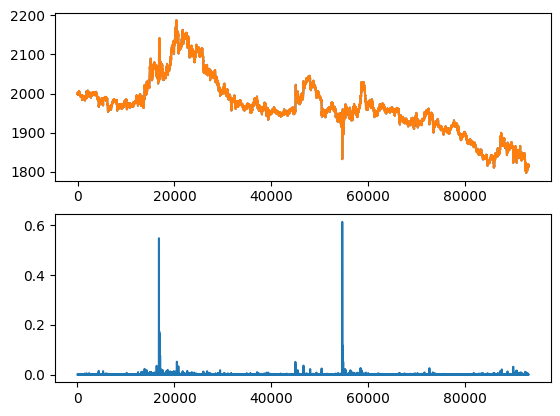

In [371]:
"""
Median and mean
"""
import statsmodels.api as sm
df = pd.concat([squid_data['adjusted_mid_change'].rolling(5).mean().shift(1),squid_data['adjusted_mid_change'].rolling(5).median().shift(1),squid_data['adjusted_mid_change']],axis=1)
df = df.dropna()
df = df.clip(-0.0075,0.0075)
X = df.iloc[:,0:2]
Y = df.iloc[:,2]

model = sm.OLS(Y,X)
results = model.fit()
# print(results.params)
# model = sm.OLS(sm.add_constant(df.iloc[:,0].values), df.iloc[:,1].values)
# results = model.fit()
# print(results.params)
predictions = results.predict(X)
predicted = squid_data['adjusted_mid']*(1+predictions)
MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
fig,ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(predicted)

ax[1].plot((predicted-squid_data['adjusted_mid'])**2)
MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
print("MSE loss: ", MSE_loss)
print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)


Minimum loss: 0.0007280266377318144 
MSE loss ave magnitude ratio:  1.5347323565987407 
Rolling Window Size:  2


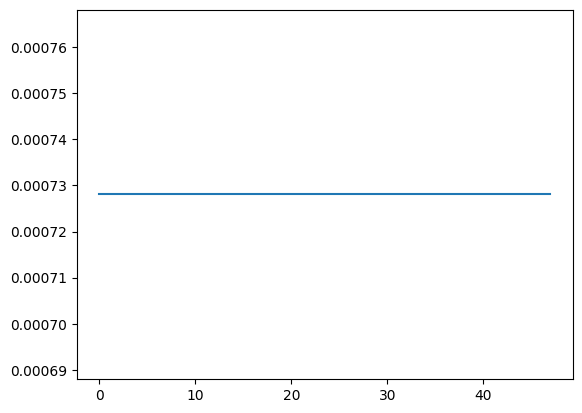

In [372]:
"""
Param search for rolling window:
"""

import statsmodels.api as sm
fig,ax = plt.subplots()
MSE_losses = []
for n in range(2,50):
    df = pd.concat([squid_data['adjusted_mid_change'].rolling(5).mean().shift(1),squid_data['adjusted_mid_change'].rolling(5).median().shift(1),squid_data['adjusted_mid_change']],axis=1)
    df = df.dropna()
    df = df.clip(-0.0075,0.0075)
    X = df.iloc[:,0:2]
    Y = df.iloc[:,2]

    model = sm.OLS(Y,X)
    results = model.fit()
    # print(results.params)
    # model = sm.OLS(sm.add_constant(df.iloc[:,0].values), df.iloc[:,1].values)
    # results = model.fit()
    # print(results.params)
    predictions = results.predict(X)
    predicted = squid_data['adjusted_mid']*(1+predictions)
    MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
    # print("rolling window: ", n)
    # print("MSE loss: ", MSE_loss)
    MSE_losses.append(MSE_loss)
    # print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)
ax.plot(MSE_losses)
print("\nMinimum loss:", min(MSE_losses), "\nMSE loss ave magnitude ratio: ", min(MSE_losses)/ave_mag, "\nRolling Window Size: ", 2+np.argmin(MSE_losses))


In [373]:
"""
Setting up other variables for multiple linear regression
- total volume pressure
- adjusted total volume pressure
- spread
- adjusted spread
- microprice change
- microprice spread ratio
- adjusted microprice change
- adjusted microprice adjusted spread ratio
- bidrange
- askrange
- bidrange to askrange ratio
- highest ask bid change
- highest vol bid change
- overall weighted bid change
- overall weighted ask change
- overall weighted bid-ask spread
- overall weighted bid-ask microprice change
- overall weighted bid-ask microprice spread ratio
"""

total_bid = squid_data[[f'bid_volume_{i}' for i in range(1,4)]].sum(axis=1)
total_ask = squid_data[[f'ask_volume_{i}' for i in range(1,4)]].sum(axis=1)
squid_data['total_volume_pressure'] = total_bid/(total_bid+total_ask)
print(np.isinf(squid_data['total_volume_pressure']).any())

highest_bid_vol = squid_data.apply(lambda row: row[f"bid_volume_{row['highest_vol_bid_idx']}"],axis=1)
highest_ask_vol = squid_data.apply(lambda row: row[f"ask_volume_{row['highest_vol_ask_idx']}"],axis=1)
squid_data['adjusted_total_volume_pressure'] = highest_bid_vol/(highest_bid_vol+highest_ask_vol)
print(np.isinf(squid_data['adjusted_total_volume_pressure']).any())

spread = squid_data['ask_price_1'] - squid_data['bid_price_1']
squid_data['spread'] = spread

adjusted_spread = squid_data['highest_vol_ask'] - squid_data['highest_vol_bid']
squid_data['adjusted_spread'] = adjusted_spread

default_micro_prices = (squid_data['ask_price_1']*squid_data['ask_volume_1'] + squid_data['bid_price_1']*squid_data['bid_volume_1'])/(squid_data['bid_volume_1']+squid_data['ask_volume_1'])
squid_data['micro_price_change'] = default_micro_prices.pct_change()
squid_data['micro_price_spread_ratio'] = (default_micro_prices- squid_data['bid_price_1'])/spread
print(np.isinf(squid_data['micro_price_change']).any())
print(np.isinf(squid_data['micro_price_spread_ratio']).any())

adjusted_micro_prices = (squid_data['highest_vol_ask']*highest_ask_vol + squid_data['highest_vol_bid']*highest_bid_vol)/(highest_bid_vol+highest_ask_vol)
squid_data['adjusted_microprice_change'] = adjusted_micro_prices.pct_change()
squid_data['adjusted_micro_price_spread_ratio'] = (adjusted_micro_prices- squid_data['highest_vol_bid'])/spread
print(np.isinf(squid_data['adjusted_microprice_change']).any())
print(np.isinf(squid_data['adjusted_micro_price_spread_ratio']).any())

bidrange = squid_data[[f'bid_price_{i}' for i in range(1,4)]].max(axis=1) - squid_data[[f'bid_price_{i}' for i in range(1,4)]].min(axis=1)
askrange = squid_data[[f'ask_price_{i}' for i in range(1,4)]].max(axis=1) - squid_data[[f'ask_price_{i}' for i in range(1,4)]].min(axis=1)
squid_data['bidrange'] = bidrange + 1
squid_data['askrange'] = askrange + 1

squid_data['highest_vol_bid_change'] = squid_data['highest_vol_bid'].pct_change()
squid_data['highest_vol_ask_change'] = squid_data['highest_vol_ask'].pct_change()

weighted_bid = pd.concat([(squid_data[f'bid_price_{i}']*squid_data[f'bid_volume_{i}']).fillna(0) for i in range(1,4)],axis=1).sum(axis=1)
weighted_bid /= total_bid
weighted_ask = pd.concat([(squid_data[f'ask_price_{i}']*squid_data[f'ask_volume_{i}']).fillna(0) for i in range(1,4)],axis=1).sum(axis=1)
weighted_ask /= total_ask
squid_data['overall_weighted_bid_change'] = weighted_bid.pct_change()
squid_data['overall_weighted_ask_change'] = weighted_ask.pct_change()
squid_data['overall_weighted_spread'] = weighted_ask-weighted_bid
squid_data['overall_weighted microprice change'] = ((weighted_bid*total_ask + weighted_bid*total_bid)/(total_bid+total_ask)).pct_change()
squid_data['overall_weighted microprice spread_ratio'] = ((weighted_bid*total_ask + weighted_bid*total_bid)/(total_bid+total_ask) - weighted_bid)/squid_data['overall_weighted_spread']
print(np.isinf(squid_data['overall_weighted_bid_change']).any())
print(np.isinf(squid_data['overall_weighted_ask_change']).any())
print(np.isinf(squid_data['overall_weighted_spread']).any())
print(np.isinf(squid_data['overall_weighted microprice change']).any())
print(np.isinf(squid_data['overall_weighted microprice spread_ratio']).any())


False
False
False
False
False
False
False
False
False
False
False


MSE loss:  2.0745693078496457
MSE loss ave magnitude ratio:  4373.340861102354


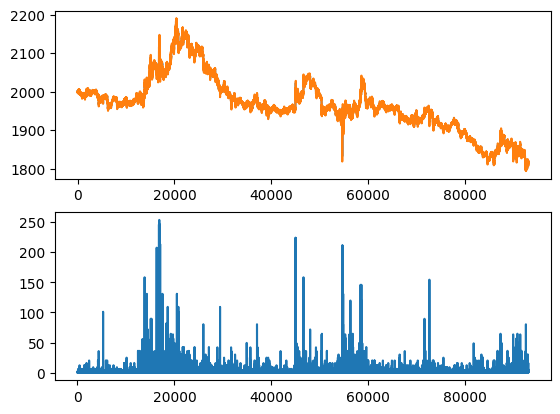

In [374]:
"""
All new features
"""
new_cols = list(squid_data.columns)[23:]
df = pd.concat([squid_data['adjusted_mid_change'],squid_data['adjusted_mid_change'].shift(1),squid_data[new_cols]],axis=1)
df = df.dropna()
df = df.clip(-0.0075,0.0075)
Y = df.iloc[:,0]
X = df.iloc[:,1:]
model = sm.OLS(Y, X)
results = model.fit()
predictions = results.predict(X)
predicted = squid_data['adjusted_mid']*(1+predictions)

fig,ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(predicted)

ax[1].plot((predicted-squid_data['adjusted_mid'])**2)
MSE_loss = ((predicted-squid_data['adjusted_mid'])**2).mean()
print("MSE loss: ", MSE_loss)
print("MSE loss ave magnitude ratio: ", MSE_loss/ave_mag)

# Kalman filter

In [375]:
import numpy as np
import matplotlib.pyplot as plt

windows = []
mse_losses = []
for i in range(1,20):
    for j in range(1,20):
        # Assume these are your observed series
        df = pd.concat([squid_data['adjusted_mid'],
                        squid_data['adjusted_mid'].shift(i),
                        np.sign(squid_data['adjusted_mid']-squid_data['adjusted_mid'].shift(j))],axis=1)
        df = df.dropna()
        x = df.iloc[:,1:].values
        y = df.iloc[:,0].values # shape (T,)
        T = len(y)

        T = len(y)
        n_params = 2
        beta = np.zeros(n_params)        # Initial state vector
        P = np.eye(n_params)             # Initial state covariance
        Q = 1e-5 * np.eye(n_params)      # Process noise
        R = 0.01                         # Measurement noise

        beta_estimates = np.zeros((T, n_params))

        for t in range(T):
            xt = x[t]                    # shape (n_params,)
            yt = y[t]

            # Predict
            beta_prior = beta
            P_prior = P + Q

            # Kalman gain
            S = xt @ P_prior @ xt.T + R
            K = P_prior @ xt / S         # shape (n_params,)

            # Update
            beta = beta_prior + K * (yt - xt @ beta_prior)
            P = P_prior - np.outer(K, xt) @ P_prior

            beta_estimates[t] = beta
            
        y_pred = np.sum(x * beta_estimates, axis=1)
        # plt.plot(y)
        # plt.plot(y_pred)
        mse_loss = (y-y_pred)**2
        windows.append((i,j))
        mse_losses.append(np.mean(mse_loss))
print(min(mse_losses), windows[np.argmin(mse_losses)])

2.4539786058274907e-07 (3, 3)


2.4539786058274907e-07


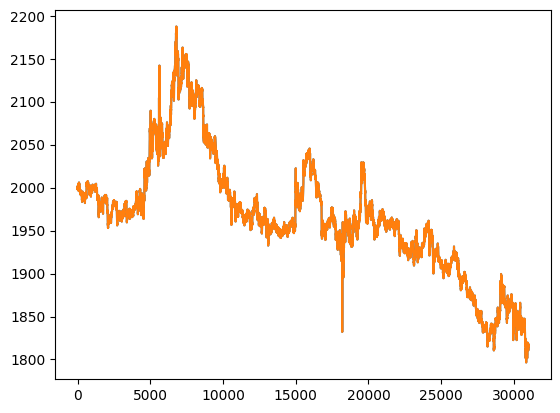

In [376]:
# Assume these are your observed series
df = pd.concat([squid_data['adjusted_mid'],
                squid_data['adjusted_mid'].shift(3),
                np.sign(squid_data['adjusted_mid']-squid_data['adjusted_mid'].shift(3))],axis=1)
df = df.dropna()
x = df.iloc[:,1:].values
y = df.iloc[:,0].values # shape (T,)
T = len(y)

T = len(y)
n_params = 2
beta = np.zeros(n_params)        # Initial state vector
P = np.eye(n_params)             # Initial state covariance
Q = 1e-5 * np.eye(n_params)      # Process noise
R = 0.01                         # Measurement noise

beta_estimates = np.zeros((T, n_params))

for t in range(T):
    xt = x[t]                    # shape (n_params,)
    yt = y[t]

    # Predict
    beta_prior = beta
    P_prior = P + Q

    # Kalman gain
    S = xt @ P_prior @ xt.T + R
    K = P_prior @ xt / S         # shape (n_params,)

    # Update
    beta = beta_prior + K * (yt - xt @ beta_prior)
    P = P_prior - np.outer(K, xt) @ P_prior

    beta_estimates[t] = beta
    
y_pred = np.sum(x * beta_estimates, axis=1)
plt.plot(y)
plt.plot(y_pred)
mse_loss = (y-y_pred)**2
print(np.mean(mse_loss))

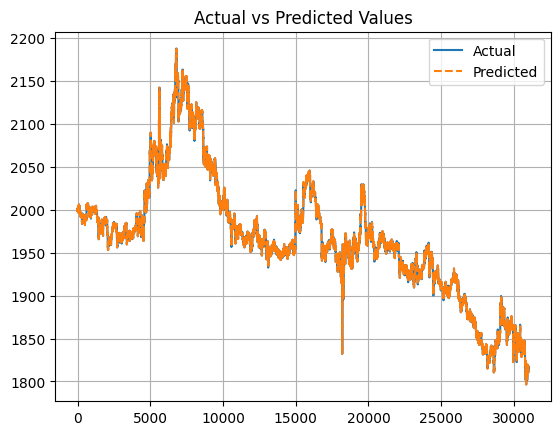

Mean Squared Error (MSE): 2.453978605827345e-07


In [377]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter:
    def __init__(self, n_params=2, Q=1e-5, R=0.01):
        # Initialize parameters
        self.n_params = n_params  # Number of parameters to estimate (e.g., 2)
        
        # Initial estimates (beta) and covariance (P)
        self.beta = np.zeros(n_params)  # Initial beta estimate
        self.P = np.eye(n_params)  # Initial covariance matrix (identity)
        
        # Process noise covariance (Q) and measurement noise covariance (R)
        self.Q = Q * np.eye(n_params)
        self.R = R
        
    def update(self, x_t, y_t):
        """
        Update the Kalman filter with a new observation (x_t, y_t) at each time step.
        
        x_t : Array of input variables at time t (size n_params,)
        y_t : Actual observed value at time t
        """
        # Predict step
        beta_prior = self.beta
        P_prior = self.P + self.Q
        
        # Calculate the Kalman Gain
        S = np.dot(x_t, np.dot(P_prior, x_t)) + self.R
        K = np.dot(P_prior, x_t) / S
        
        # Update the estimate of beta
        y_pred = np.dot(x_t, beta_prior)
        self.beta = beta_prior + K * (y_t - y_pred)
        
        # Update the covariance matrix
        self.P = P_prior - np.outer(K, x_t) @ P_prior
        
        return self.beta
    
    def predict(self, x_t):
        """
        Predict the next value based on the current state (beta).
        
        x_t : Array of input variables at time t (size n_params,)
        
        Returns:
        y_pred : The predicted value at time t
        """
        return np.dot(x_t, self.beta)

# Create an instance of the KalmanFilter class
kf = KalmanFilter(n_params=2)  # For example, using 2 parameters

# Example usage
predictions = []
y_actual = []  # To store the actual y values for comparison

# Assuming we get x_t and y_t at each time step
for t in range(len(df)):  # Assuming df is your data with x and y
    x_t = df.iloc[t, 1:].values  # Get the current x values (input variables)
    y_t = df.iloc[t, 0]  # Get the current y value (observed value)
    
    # Update the Kalman filter with the new data and make a prediction
    kf.update(x_t, y_t)
    y_pred = kf.predict(x_t)
    
    predictions.append(y_pred)
    y_actual.append(y_t)

# After all updates, you can compare the predicted values with the actual ones
predictions = np.array(predictions)
y_actual = np.array(y_actual)

# Plotting the results
plt.plot(y_actual, label="Actual")
plt.plot(predictions, label="Predicted", linestyle="--")
plt.legend()
plt.title("Actual vs Predicted Values")
plt.grid()
plt.show()

# Optionally, compute the Mean Squared Error (MSE)
mse = np.mean((y_actual - predictions)**2)
print("Mean Squared Error (MSE):", mse)


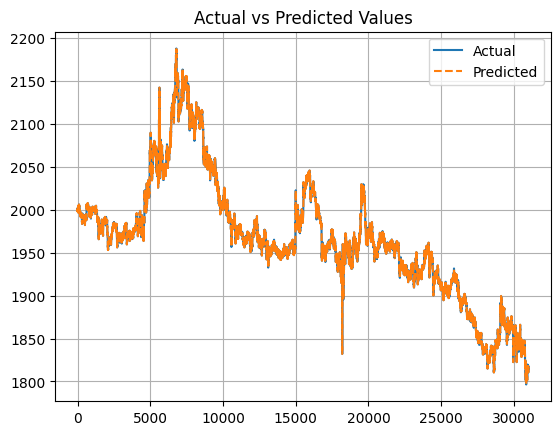

Mean Squared Error (MSE): 2.473696025758705e-07


In [378]:
"""
Only lists
"""
import matplotlib.pyplot as plt

class KalmanFilter:
    def __init__(self, n_params=2, Q=1e-5, R=0.01):
        # Initialize parameters
        self.n_params = n_params  # Number of parameters to estimate (e.g., 2)
        
        # Initial estimates (beta) and covariance (P)
        self.beta = [0.0] * n_params  # Initial beta estimate
        self.P = [[1.0 if i == j else 0.0 for i in range(n_params)] for j in range(n_params)]  # Identity covariance matrix
        
        # Process noise covariance (Q) and measurement noise covariance (R)
        self.Q = [[Q if i == j else 0.0 for i in range(n_params)] for j in range(n_params)]  # Process noise covariance
        self.R = R  # Measurement noise covariance
        
    def update(self, x_t, y_t):
        """
        Update the Kalman filter with a new observation (x_t, y_t) at each time step.
        
        x_t : Array of input variables at time t (size n_params,)
        y_t : Actual observed value at time t
        """
        # Predict step
        beta_prior = self.beta
        P_prior = [row[:] for row in self.P]  # Copy the covariance matrix
        for i in range(self.n_params):
            P_prior[i][i] += self.Q[i][i]  # Add process noise
        
         # Kalman gain
        S = sum(x_t[i] * sum(P_prior[i][j] * x_t[j] for j in range(self.n_params)) for i in range(self.n_params)) + self.R
        K = [sum(P_prior[i][j] * x_t[j] for j in range(self.n_params)) / S for i in range(self.n_params)]
        
        # Update the estimate of beta
        y_pred = sum(x_t[i] * beta_prior[i] for i in range(self.n_params))
        self.beta = [beta_prior[i] + K[i] * (y_t - y_pred) for i in range(self.n_params)]
        
        # Update the covariance matrix
        self.P = [[P_prior[i][j] - K[i] * x_t[j] * P_prior[i][j] for j in range(self.n_params)] for i in range(self.n_params)]
        
        return self.beta
    
    def predict(self, x_t):
        """
        Predict the next value based on the current state (beta).
        
        x_t : List of input variables at time t (size n_params,)
        
        Returns:
        y_pred : The predicted value at time t
        """
        return sum(x_t[i] * self.beta[i] for i in range(self.n_params))  

# Create an instance of the KalmanFilter class
kf = KalmanFilter(n_params=2)  # For example, using 2 parameters

# Example usage
predictions = []
y_actual = []  # To store the actual y values for comparison

# Assuming we get x_t and y_t at each time step
for t in range(len(df)):  # Assuming df is your data with x and y
    x_t = df.iloc[t, 1:].values.tolist()  # Get the current x values (input variables)
    y_t = df.iloc[t, 0]  # Get the current y value (observed value)
    
    # Update the Kalman filter with the new data and make a prediction
    kf.update(x_t, y_t)
    y_pred = kf.predict(x_t)
    
    predictions.append(y_pred)
    y_actual.append(y_t)

# After all updates, you can compare the predicted values with the actual ones
predictions = predictions
y_actual = y_actual

# Plotting the results
plt.plot(y_actual, label="Actual")
plt.plot(predictions, label="Predicted", linestyle="--")
plt.legend()
plt.title("Actual vs Predicted Values")
plt.grid()
plt.show()

# Optionally, compute the Mean Squared Error (MSE)
mse = sum((y_actual[i] - predictions[i])**2 for i in range(len(y_actual))) / len(y_actual)
print("Mean Squared Error (MSE):", mse)

# Trend

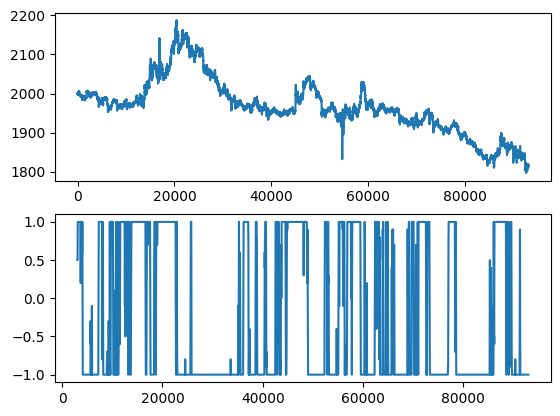

In [379]:
fig, ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[1].plot(np.sign(squid_data['adjusted_mid']-squid_data['adjusted_mid'].rolling(1000).mean()).rolling(20).mean())

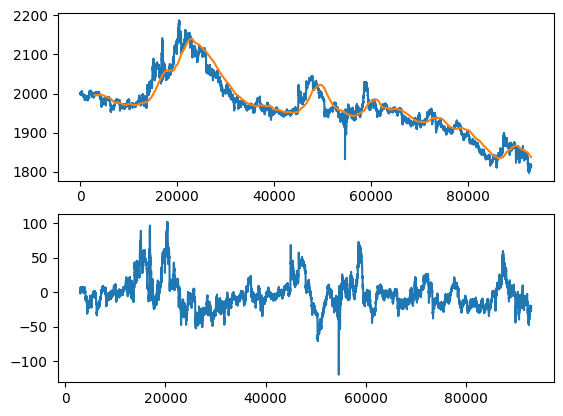

In [380]:
fig, ax = plt.subplots(nrows=2)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(squid_data['adjusted_mid'].rolling(1000).mean())
ax[1].plot(squid_data['adjusted_mid']-squid_data['adjusted_mid'].rolling(1000).mean())

In [381]:
dfs = [pd.read_csv('../../round_data/prices_round_1_day_-2.csv',delimiter=';'), pd.read_csv('../../round_data/prices_round_1_day_-1.csv',delimiter=';'), pd.read_csv('../../round_data/prices_round_1_day_0.csv',delimiter=';'), processor.activities_log]

In [382]:
dfs = [df[df['product']=='SQUID_INK'] for df in dfs]

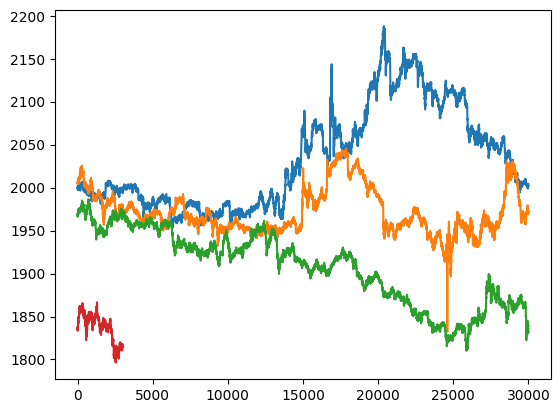

In [383]:
for df in dfs:
    plt.plot(df.mid_price)

In [384]:
kelp_data = price_data[price_data['product'] == "KELP"].copy()
resin_data = price_data[price_data['product'] == "RAINFOREST_RESIN"].copy()
squid_data = price_data[price_data['product'] == "SQUID_INK"].copy()

kelp_trades = trade_history_data[trade_history_data['symbol'] == "KELP"].copy()
resin_trades = trade_history_data[trade_history_data['symbol'] == "RAINFOREST_RESIN"].copy()
squid_trades = trade_history_data[trade_history_data['symbol'] == "SQUID_INK"].copy()

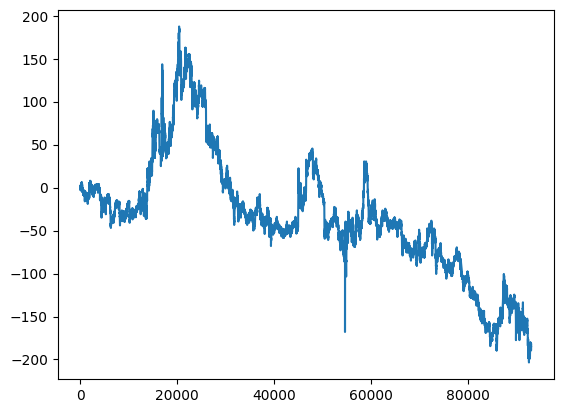

In [385]:
squid_shift = squid_data.mid_price-2000
plt.plot(squid_shift)


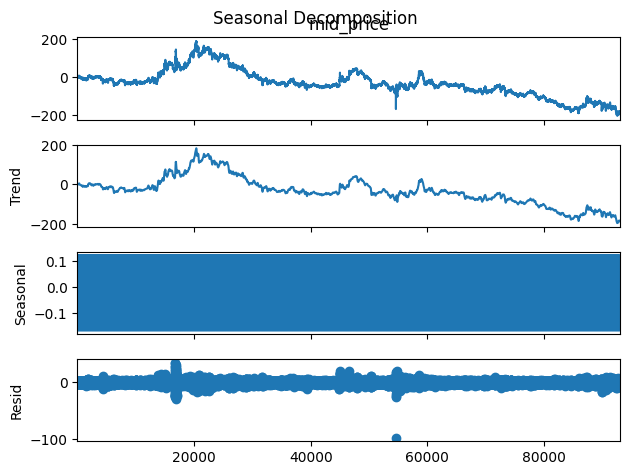

In [386]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

price_series = squid_shift
result = seasonal_decompose(price_series, model='additive', period=30)

trend = result.trend
detrended = price_series - trend
detrended = detrended.dropna()

# Optional plot
result.plot()
plt.suptitle("Seasonal Decomposition")
plt.show()

In [387]:
squid_data["highest_vol_bid_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"bid_volume_{i}"] for i in range(1,4)]),axis=1)
squid_data["highest_vol_bid"] = squid_data.apply(lambda row : row[f"bid_price_{row['highest_vol_bid_idx']}"],axis=1)

squid_data["highest_vol_ask_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"ask_volume_{i}"] for i in range(1,4)]),axis=1)
squid_data["highest_vol_ask"] = squid_data.apply(lambda row : row[f"ask_price_{row['highest_vol_ask_idx']}"],axis=1)

squid_data['adjusted_mid'] = (squid_data['highest_vol_ask']+squid_data['highest_vol_bid'])/2

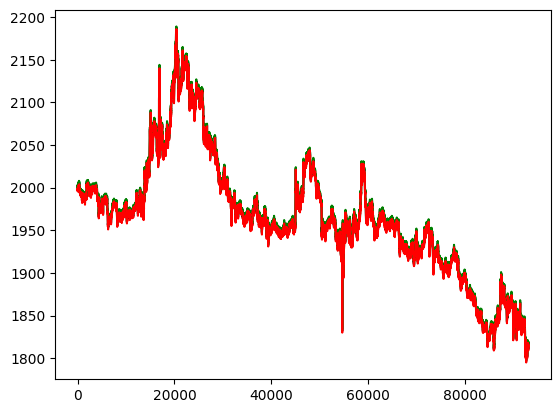

In [388]:
plt.plot(squid_data['adjusted_mid'],color='k')
plt.plot(squid_data['highest_vol_ask'],color='green')
plt.plot(squid_data['highest_vol_bid'],color='red')

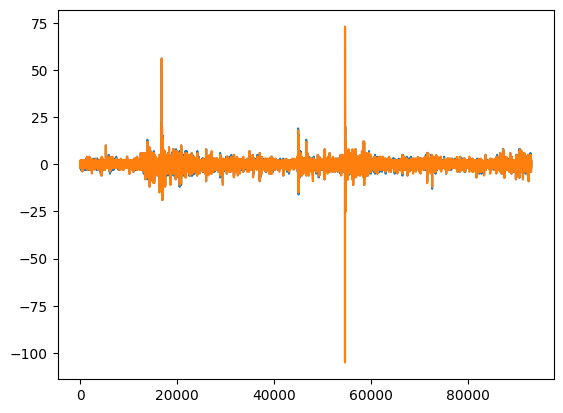

In [389]:
plt.plot(squid_data['highest_vol_ask'].diff())
plt.plot(squid_data['highest_vol_bid'].diff())

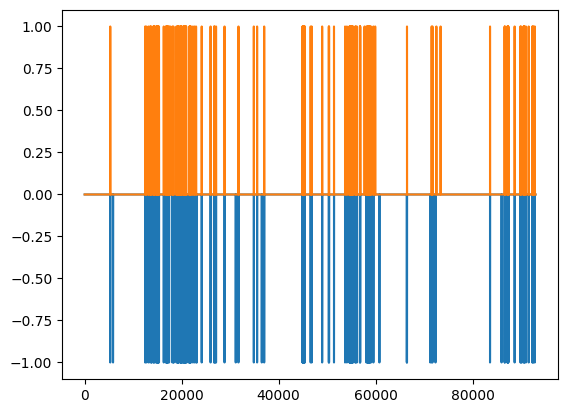

In [390]:
plt.plot(-1*(squid_data['highest_vol_ask'].diff() > 4))

plt.plot(squid_data['highest_vol_bid'].diff() > 4)

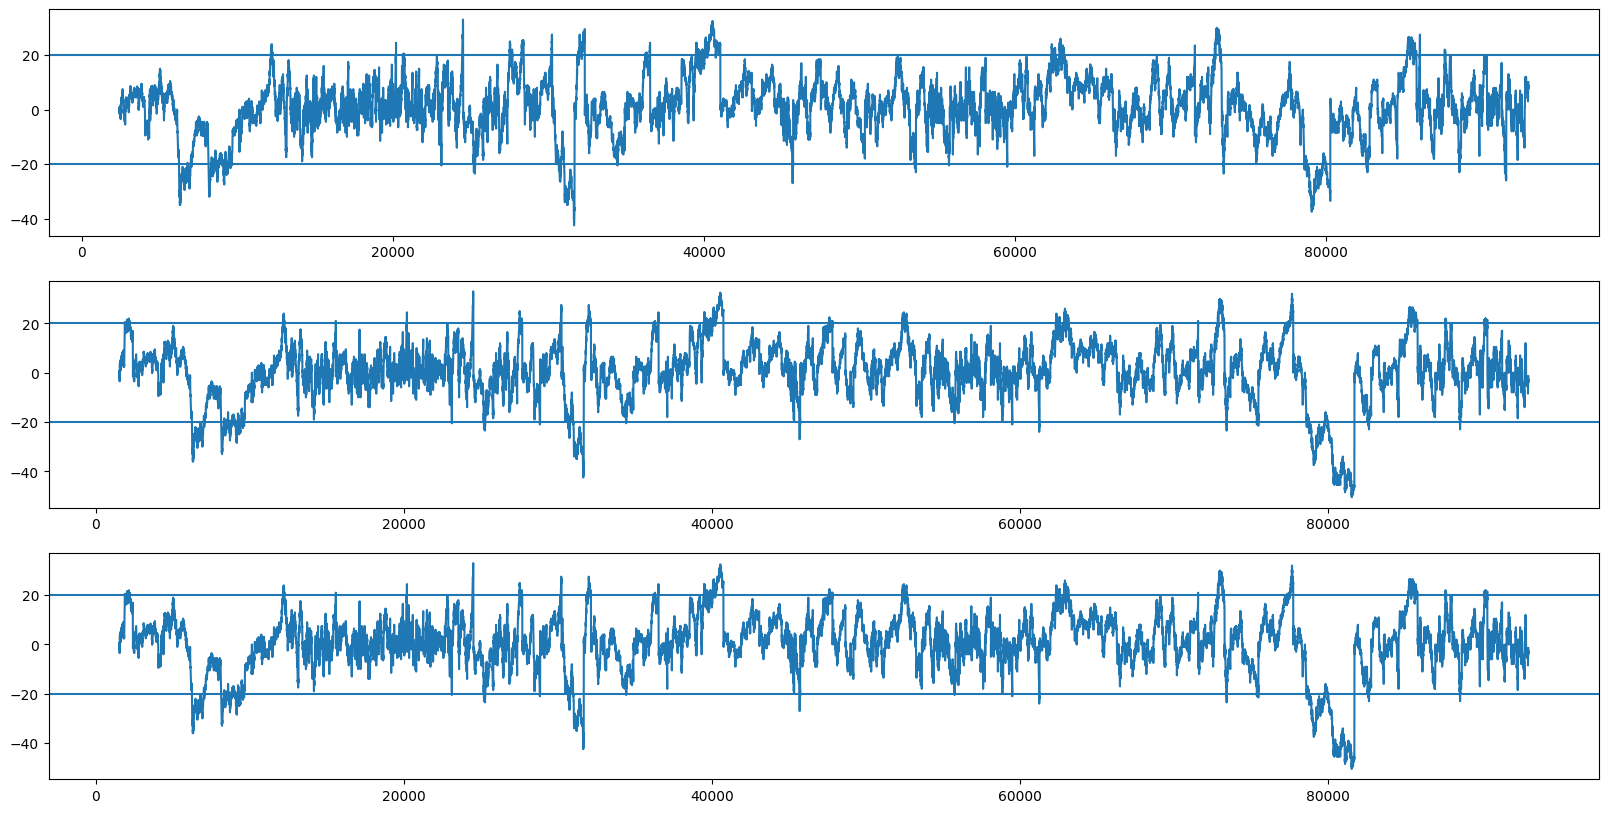

In [391]:
fig,ax = plt.subplots(nrows=3, figsize=(20,10))

masked = squid_data['adjusted_mid']*(abs(squid_data['highest_vol_bid'].diff(2)) > 5)
ax[0].plot(squid_data['adjusted_mid']-masked.replace(0,np.nan).ffill())
ax[0].axhline(20)
ax[0].axhline(-20)

masked2 = squid_data['adjusted_mid']*(abs(squid_data['highest_vol_ask'].diff(2)) > 5)
ax[1].plot(squid_data['adjusted_mid']-masked2.replace(0,np.nan).ffill())
ax[1].axhline(20)
ax[1].axhline(-20)

masked3 = squid_data['adjusted_mid']*(abs(squid_data['highest_vol_ask'].diff(2)) > 5)*(abs(squid_data['highest_vol_bid'].diff(2)) > 5)
ax[2].plot(squid_data['adjusted_mid']-masked2.replace(0,np.nan).ffill())
ax[2].axhline(20)
ax[2].axhline(-20)


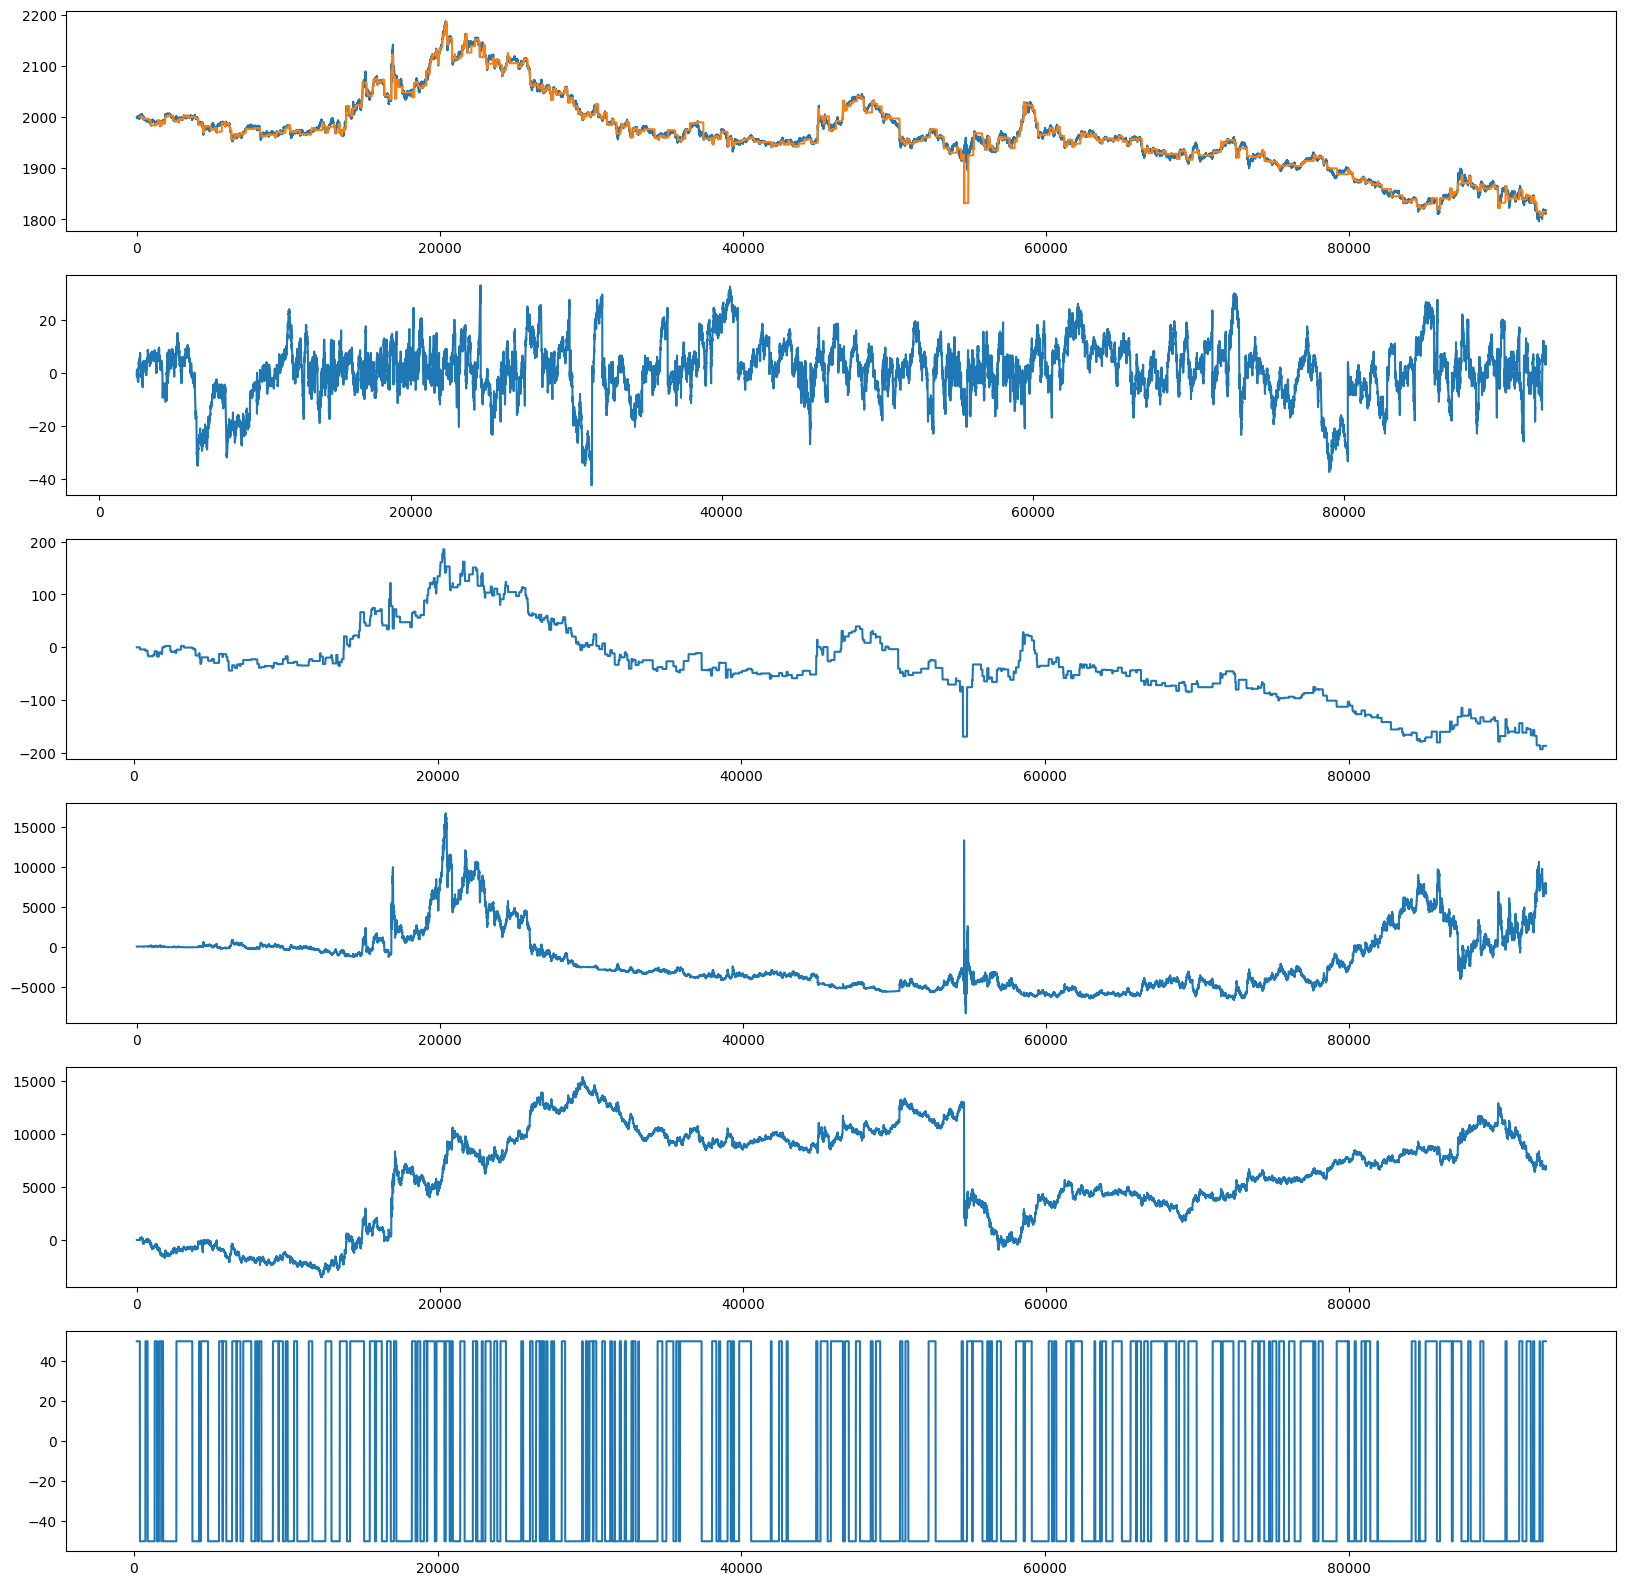

In [392]:
fig,ax = plt.subplots(nrows=6,figsize=(20,20))
limit = 5
limit = ((squid_data['adjusted_mid'].pct_change()*100).rolling(10).std())*60
masked3 = squid_data['adjusted_mid']*(abs(squid_data['highest_vol_ask'].diff(2)) > limit)*(abs(squid_data['highest_vol_bid'].diff(2)) > limit)
ax[0].plot(squid_data['adjusted_mid'])
ax[0].plot(masked3.replace(0,np.nan).ffill())
ax[1].plot(squid_data['adjusted_mid']-masked.replace(0,np.nan).ffill())
ax[2].plot(masked3.replace(0,np.nan).ffill().diff().cumsum())
ax[3].plot((squid_data['adjusted_mid'].diff()*(masked3.replace(0,np.nan).ffill().diff().cumsum())).fillna(0).cumsum())

signals = (squid_data['highest_vol_ask'].diff(2) > limit).astype(int)*(squid_data['highest_vol_bid'].diff(2) > limit).astype(int)
signals -= (squid_data['highest_vol_ask'].diff(2) < -limit).astype(int)*(squid_data['highest_vol_bid'].diff(2) < -limit).astype(int)
signals = signals.replace(0,np.nan).ffill()*50
ax[4].plot(((squid_data['adjusted_mid'].diff().shift(-1))*signals).fillna(0).cumsum())
ax[5].plot(signals)

Trying every single model I know

In [1]:
"""
One layer neural network
"""

'\nOne layer neural network\n'

In [18]:
import torch.nn as nn
import torch

In [9]:
kelp_data = price_data[price_data['product'] == "KELP"].copy()
resin_data = price_data[price_data['product'] == "RAINFOREST_RESIN"].copy()
squid_data = price_data[price_data['product'] == "SQUID_INK"].copy()

kelp_trades = trade_history_data[trade_history_data['symbol'] == "KELP"].copy()
resin_trades = trade_history_data[trade_history_data['symbol'] == "RAINFOREST_RESIN"].copy()
squid_trades = trade_history_data[trade_history_data['symbol'] == "SQUID_INK"].copy()

In [ ]:
"""
Feature engineering
"""
squid_data["highest_vol_bid_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"bid_volume_{i}"] for i in range(1,4)]),axis=1)
squid_data["highest_vol_bid"] = squid_data.apply(lambda row : row[f"bid_price_{row['highest_vol_bid_idx']}"],axis=1)

squid_data["highest_vol_ask_idx"] = squid_data.apply(lambda row : 1 + np.argmax([row.fillna(0)[f"ask_volume_{i}"] for i in range(1,4)]),axis=1)
squid_data["highest_vol_ask"] = squid_data.apply(lambda row : row[f"ask_price_{row['highest_vol_ask_idx']}"],axis=1)

squid_data['adjusted_mid'] = (squid_data['highest_vol_ask']+squid_data['highest_vol_bid'])/2

total_bid = squid_data[[f'bid_volume_{i}' for i in range(1,4)]].sum(axis=1)
total_ask = squid_data[[f'ask_volume_{i}' for i in range(1,4)]].sum(axis=1)
squid_data['total_volume_pressure'] = total_bid/(total_bid+total_ask)
print(np.isinf(squid_data['total_volume_pressure']).any())

highest_bid_vol = squid_data.apply(lambda row: row[f"bid_volume_{row['highest_vol_bid_idx']}"],axis=1)
highest_ask_vol = squid_data.apply(lambda row: row[f"ask_volume_{row['highest_vol_ask_idx']}"],axis=1)
squid_data['adjusted_total_volume_pressure'] = highest_bid_vol/(highest_bid_vol+highest_ask_vol)
print(np.isinf(squid_data['adjusted_total_volume_pressure']).any())

spread = squid_data['ask_price_1'] - squid_data['bid_price_1']
squid_data['spread'] = spread

adjusted_spread = squid_data['highest_vol_ask'] - squid_data['highest_vol_bid']
squid_data['adjusted_spread'] = adjusted_spread

default_micro_prices = (squid_data['ask_price_1']*squid_data['ask_volume_1'] + squid_data['bid_price_1']*squid_data['bid_volume_1'])/(squid_data['bid_volume_1']+squid_data['ask_volume_1'])
squid_data['micro_price_change'] = default_micro_prices.pct_change()
squid_data['micro_price_spread_ratio'] = (default_micro_prices- squid_data['bid_price_1'])/spread
print(np.isinf(squid_data['micro_price_change']).any())
print(np.isinf(squid_data['micro_price_spread_ratio']).any())

adjusted_micro_prices = (squid_data['highest_vol_ask']*highest_ask_vol + squid_data['highest_vol_bid']*highest_bid_vol)/(highest_bid_vol+highest_ask_vol)
squid_data['adjusted_microprice_change'] = adjusted_micro_prices.pct_change()
squid_data['adjusted_micro_price_spread_ratio'] = (adjusted_micro_prices- squid_data['highest_vol_bid'])/spread
print(np.isinf(squid_data['adjusted_microprice_change']).any())
print(np.isinf(squid_data['adjusted_micro_price_spread_ratio']).any())

bidrange = squid_data[[f'bid_price_{i}' for i in range(1,4)]].max(axis=1) - squid_data[[f'bid_price_{i}' for i in range(1,4)]].min(axis=1)
askrange = squid_data[[f'ask_price_{i}' for i in range(1,4)]].max(axis=1) - squid_data[[f'ask_price_{i}' for i in range(1,4)]].min(axis=1)
squid_data['bidrange'] = bidrange + 1
squid_data['askrange'] = askrange + 1

squid_data['highest_vol_bid_change'] = squid_data['highest_vol_bid'].diff()
squid_data['highest_vol_ask_change'] = squid_data['highest_vol_ask'].diff()

squid_data['best_bid_change'] = squid_data['bid_price_1'].diff()
squid_data['best_ask_change'] = squid_data['ask_price_1'].diff()

weighted_bid = pd.concat([(squid_data[f'bid_price_{i}']*squid_data[f'bid_volume_{i}']).fillna(0) for i in range(1,4)],axis=1).sum(axis=1)
weighted_bid /= total_bid
weighted_ask = pd.concat([(squid_data[f'ask_price_{i}']*squid_data[f'ask_volume_{i}']).fillna(0) for i in range(1,4)],axis=1).sum(axis=1)
weighted_ask /= total_ask
squid_data['overall_weighted_bid_change'] = weighted_bid.diff()
squid_data['overall_weighted_ask_change'] = weighted_ask.diff()
squid_data['overall_weighted_spread'] = weighted_ask-weighted_bid
squid_data['overall_weighted microprice change'] = ((weighted_bid*total_ask + weighted_bid*total_bid)/(total_bid+total_ask)).pct_change()
squid_data['overall_weighted microprice spread_ratio'] = ((weighted_bid*total_ask + weighted_bid*total_bid)/(total_bid+total_ask) - weighted_bid)/squid_data['overall_weighted_spread']
print(np.isinf(squid_data['overall_weighted_bid_change']).any())
print(np.isinf(squid_data['overall_weighted_ask_change']).any())
print(np.isinf(squid_data['overall_weighted_spread']).any())
print(np.isinf(squid_data['overall_weighted microprice change']).any())
print(np.isinf(squid_data['overall_weighted microprice spread_ratio']).any())

False
False
False
False
False
False
False
False
False
False
False


In [143]:
features = ["highest_vol_bid_change",
            "highest_vol_ask_change",
            "spread",
            "adjusted_spread",
            "total_volume_pressure",
            "adjusted_total_volume_pressure",
            "adjusted_microprice_change",
            'adjusted_micro_price_spread_ratio',
            'bidrange',
            'askrange',
            "overall_weighted_bid_change",
            "overall_weighted_ask_change",
            "overall_weighted_spread",
            "overall_weighted microprice change",
            "overall_weighted microprice spread_ratio"
            ]

X = squid_data[features].dropna()
y = squid_data[["highest_vol_bid_change","highest_vol_ask_change"]].shift(-1).dropna()
X.shape, y.shape

((30999, 15), (30999, 2))

In [144]:
X_tens = torch.tensor(X.values).to(device='cuda:0',dtype=torch.float32)
y_tens = torch.tensor(y.values).to(device='cuda:0',dtype=torch.float32)

In [145]:
n = int(len(X_tens)*0.5)
train, test = X_tens[:n,:], X_tens[n:,:]
y_train, y_test = y_tens[:n,:], y_tens[n:,:]

In [146]:
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(X_tens.shape[1],y_tens.shape[1])
).to(device='cuda:0')

In [147]:
"""
train loop
"""
import torch.optim as optim

epochs = 100000

optimizer = optim.SGD(model.parameters(),lr=0.01)
criterion = nn.MSELoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.9)

losses = []
val_losses = []
best_loss = 1e6
patience = 10
trigger = 0

for epoch in range(epochs):
    model.train()
    outputs = model(train)
    loss = criterion(outputs,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    losses.append(loss.item())
        
    model.eval()
    outputs = model(test)
    loss = criterion(outputs,y_test)
    val_losses.append(loss.item())    
    if loss.item() > best_loss:
        trigger += 1
        if trigger == patience:
            break
    else:
        trigger = 0
        best_loss = loss.item()
        
    if epoch%5000==0:
        print(loss.item(),current_lr)

2.6532034873962402 0.01
0.0017200922593474388 0.008100000000000001
0.000985253369435668 0.005904900000000002
0.0006846655742265284 0.004782969000000002
0.0005295550217851996 0.003486784401000002
0.0004412011185195297 0.0028242953648100018
0.00038557907100766897 0.0020589113209464917
0.0003493466938380152 0.0016677181699666583
0.0003243228420615196 0.001215766545905694
0.00030692058498971164 0.0009847709021836122
0.00029421813087537885 0.0007178979876918532
0.00028502463828772306 0.0005814973700304011
0.0002781022631097585 0.0004239115827521625
0.00027309914003126323 0.00034336838202925164
0.00026923741097562015 0.0002503155504993245
0.00026636343682184815 0.00020275559590445286
0.0002642291656229645 0.00014780882941434616
0.00026249614893458784 0.00011972515182562039
0.00026133263600058854 8.727963568087727e-05
0.00026039546355605125 7.06965049015106e-05


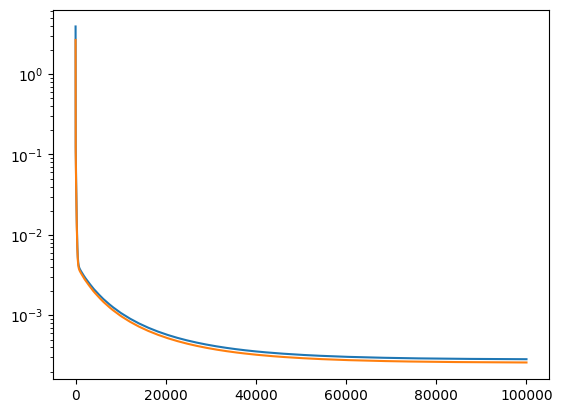

In [151]:
plt.plot(losses)
plt.plot(val_losses)
plt.yscale('log')

In [152]:
for w in model.parameters():
    print(w)

Parameter containing:
tensor([[ 7.8487e-01,  3.0751e-02,  2.5513e-02, -6.9503e-02, -9.4861e-02,
          9.5216e-02, -4.9669e-03,  2.0373e-02,  4.0509e-03,  1.7254e-02,
          2.2188e-01, -3.7380e-02,  5.3508e-02, -1.7075e-01, -1.0644e-01],
        [ 2.5841e-02,  8.6753e-01,  4.2633e-02,  6.6994e-02, -2.2017e-01,
          3.7897e-04,  2.1455e-01, -2.2192e-03,  3.9439e-02,  4.2349e-02,
         -3.0342e-02,  1.3684e-01, -1.1450e-01, -1.6257e-01, -6.5367e-02]],
       device='cuda:0', requires_grad=True)
Parameter containing:
tensor([-0.0551,  0.0386], device='cuda:0', requires_grad=True)


Slope: 1.0807427657438884
Intercept: -0.10237414031352893
R-squared: 0.896213645241462
P-value: 0.0
Standard error: 0.0020889442944026426


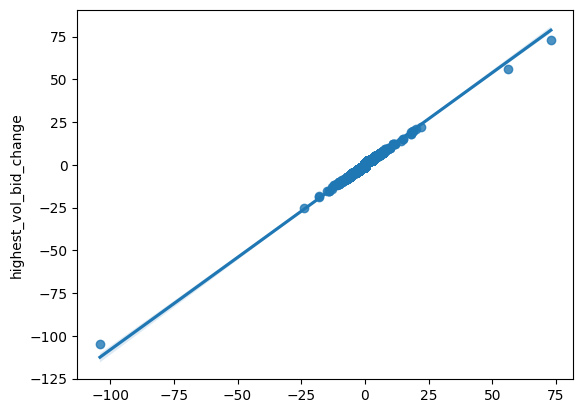

In [153]:
predicted = model(X_tens)
predicted = predicted.cpu().detach().numpy()
bid_ch = predicted[:,0].astype(int)
ask_ch = predicted[:,1].astype(int)
sns.regplot(x=bid_ch,y=squid_data['highest_vol_bid_change'].shift(-1).dropna())


from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(bid_ch, squid_data['highest_vol_bid_change'].shift(-1).dropna().values)

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")
print(f"P-value: {p_value}")
print(f"Standard error: {std_err}")